# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [1]:
import os
import time

import pandas as pd
import numpy as np
pd.set_option("display.max_columns", 200)

import pickle

from sklearn import model_selection, preprocessing

import importlib
import html_tools
import funcs

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-05-08 17:41:19.884057: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-05-08 17:41:20.087253: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compi

## Chargement des données

In [2]:
path_results = 'data/results/'
path_models = 'data/models/'

path_save = 'data/cleaned/'
df = pd.read_pickle(path_save + 'data.pickle')

In [3]:
with open(path_save + 'dico_tags', 'rb') as file:
    tags = pickle.load(file)

# Essais

In [4]:
df.columns

Index(['Title_clean', 'Title_processed', 'Body_clean', 'Body_processed',
       'Tags'],
      dtype='object')

## Convergence des classifieurs

<span style="color:red"> AJOUT </span>
* train_test_split on year ?

In [5]:
def compute_y_tag(sr_tags, tag):
    return sr_tags.apply(lambda x: tag in x)


tmp = tags['most used'].index.tolist()[0]
y_tag = compute_y_tag(df['Tags'], tmp).astype(int)

df_tags = funcs.multi_label_binarize(df['Tags'],
                                     tags['most used'].index.tolist())
display(df_tags)

x_train, x_test, y_train, y_test = model_selection.train_test_split(
                                                    df[['Title_clean',
                                                        'Body_clean',
                                                        'Title_processed',
                                                        'Body_processed'
                                                        ]],
                                                    df_tags, test_size=0.5,
                                                    random_state=7)
print('train:')
print('x:', x_train.shape)
print('y:', y_train.shape)
print('\ntest:')
print('x:', x_test.shape)
print('y:', y_test.shape)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
173250,0,1,0,0,0,0,0,0,0,0
173251,0,1,0,0,0,0,0,0,0,0
173252,0,0,0,0,1,0,0,0,0,0
173253,0,1,0,0,0,0,0,0,0,0


train:
x: (86627, 4)
y: (86627, 10)

test:
x: (86628, 4)
y: (86628, 10)


<span style="color:red"> DANS ANALYSE EXPLORATOIRE (plus avant) </span>

In [23]:
print( (df_tags.sum(axis=1) > 1).sum() )
print(len(df))

10441
173255


In [24]:
features = ['Title_processed', 'Body_processed']

In [6]:
vectorised = funcs.Vectorised()
vectorised.initialize_data('tfidf',
                           funcs.concat_str_features(x_train, features),
                           y_train,
                           min_df=100, max_df=0.95, max_features=300
                           )
vectorised.set('test', funcs.concat_str_features(x_test, features))

vocaublary length: 300


In [7]:
importlib.reload(funcs)

<module 'funcs' from '/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/funcs.py'>

In [8]:
results = {}
def test_model(vectorised, model, b_scale_x):
    tmp = funcs.Vectorised()
    tmp.copy_data_from_vetorizer(vectorised)

    t0 = time.time()
    tmp.train_classifier(model, b_scale_x=b_scale_x)
    print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

    y_pred = tmp.predict('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()

    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    display(df_res)
    results[model] = df_res.iloc[-1, :]

In [9]:
vectorised.x['train']

<86627x300 sparse matrix of type '<class 'numpy.float64'>'
	with 2169507 stored elements in Compressed Sparse Row format>

In [10]:
test_model(vectorised, 'Dummy', b_scale_x=False)

elapsed time: 1.66 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
recall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
specificity,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
F1 score,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# ne converge pas
# test_model(vectorised, 'svc')

In [12]:
test_model(vectorised, 'Logistic Regression', b_scale_x=False)

elapsed time: 17.72 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,87.45,95.05,87.73,96.16,89.60,75.26,76.69,87.45,94.68,82.20
recall,69.30,79.51,58.90,77.02,71.77,45.59,24.99,55.18,62.73,30.57
specificity,98.07,99.31,98.47,99.59,98.58,97.41,99.82,99.43,99.74,99.80
F1 score,77.32,86.59,70.48,85.53,79.70,56.78,37.69,67.66,75.47,44.56


In [13]:
test_model(vectorised, 'Logistic Regression', b_scale_x=True)

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


elapsed time: 52.72 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,87.07,94.41,87.03,95.53,88.56,73.68,76.43,86.09,93.37,81.18
recall,71.30,81.72,60.77,79.32,73.62,48.86,29.99,59.22,66.36,35.28
specificity,97.94,99.19,98.32,99.50,98.38,96.98,99.78,99.31,99.66,99.75
F1 score,78.40,87.61,71.56,86.67,80.41,58.75,43.07,70.17,77.58,49.19


In [14]:
test_model(vectorised, 'SDG Classifier', b_scale_x=True)

elapsed time: 29.60 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,85.23,91.32,84.78,92.59,85.99,68.98,52.58,79.73,93.75,80.36
recall,69.05,81.74,59.51,79.81,71.18,46.14,37.18,59.57,65.13,34.42
specificity,97.67,98.71,98.02,99.15,98.02,96.41,99.21,98.91,99.68,99.74
F1 score,76.29,86.26,69.93,85.73,77.89,55.30,43.56,68.19,76.87,48.20


In [15]:
test_model(vectorised, 'Multinomial NB', b_scale_x=False)

elapsed time: 0.75 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.06,98.76,90.86,98.71,95.15,94.89,84.21,95.79,98.18,100.00
recall,41.30,49.43,22.48,48.56,55.45,2.61,0.80,15.60,21.18,0.43
specificity,99.11,99.90,99.58,99.91,99.52,99.98,100.00,99.95,99.97,100.00
F1 score,56.63,65.88,36.05,65.10,70.07,5.09,1.58,26.84,34.84,0.85


In [16]:
test_model(vectorised, 'Perceptron', b_scale_x=True)

elapsed time: 2.14 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,69.96,84.85,62.71,78.00,74.68,49.59,35.60,57.98,62.91,42.49
recall,68.42,78.86,64.05,80.39,72.65,49.26,33.73,59.69,69.12,34.70
specificity,94.29,97.66,92.92,96.96,95.80,91.33,98.56,96.88,97.04,98.57
F1 score,69.18,81.74,63.37,79.18,73.65,49.43,34.64,58.82,65.87,38.20


In [17]:
test_model(vectorised, 'Passive Aggressive Classifier', b_scale_x=True)

elapsed time: 2.91 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,72.19,80.78,61.67,78.29,67.14,48.50,25.02,62.59,62.54,35.48
recall,64.26,78.79,60.65,74.14,73.28,42.42,16.39,56.09,60.88,35.01
specificity,95.19,96.88,93.00,97.25,93.88,92.20,98.84,97.58,97.35,98.05
F1 score,68.00,79.77,61.16,76.16,70.07,45.26,19.81,59.16,61.70,35.24


<Axes: xlabel='tags', ylabel='F1 scores (%)'>

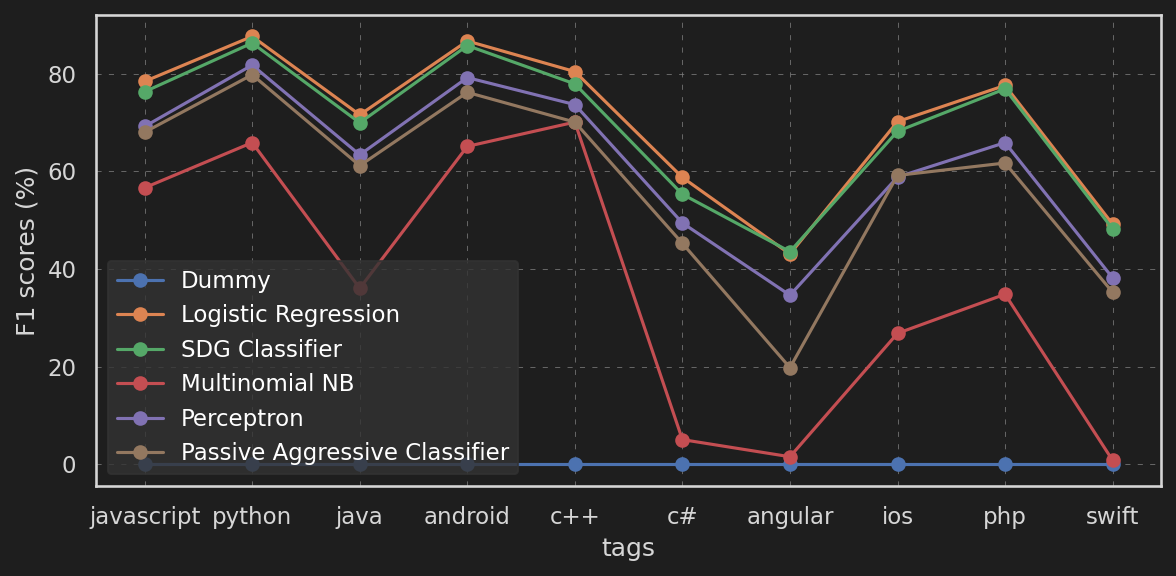

In [18]:
importlib.reload(funcs)
funcs.plot_f1_scores(results, vectorised.get_prediction_tags())

### Remarques:
SDG Classfier et Logistic regressions donnent de meilleurs résultats, mais le temps de calcul est plus long.

In [6]:
model = 'Logistic Regression'

## Optimisation des decision thresholds

In [20]:
tmp = funcs.Vectorised()
tmp.copy_data_from_vetorizer(vectorised)

t0 = time.time()
tmp.train_classifier(model)

y_pred = tmp.predict('test')
y_true = y_test.values
prediction_tags = tmp.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.set_caption('threshold "basique"'))

tmp.optimize_threshold()
y_pred = tmp.predict_optim_threshold('test')
df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res.style.set_caption('threshold "optimisé"'))

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,87.070000,94.410000,87.030000,95.530000,88.550000,73.680000,76.370000,86.090000,93.370000,81.180000
recall,71.300000,81.720000,60.770000,79.320000,73.620000,48.850000,30.030000,59.220000,66.360000,35.280000
specificity,97.940000,99.190000,98.320000,99.500000,98.380000,96.980000,99.780000,99.310000,99.660000,99.750000
F1 score,78.400000,87.610000,71.560000,86.670000,80.400000,58.750000,43.110000,70.170000,77.580000,49.190000


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,81.650000,89.870000,78.390000,91.960000,83.090000,61.000000,54.960000,76.350000,89.020000,68.630000
recall,77.630000,85.440000,68.410000,82.460000,78.430000,66.090000,45.130000,68.930000,70.380000,44.900000
specificity,96.610000,98.400000,96.500000,99.030000,97.280000,92.690000,99.130000,98.460000,99.370000,99.370000
F1 score,79.590000,87.600000,73.060000,86.950000,80.690000,63.440000,49.560000,72.450000,78.610000,54.280000


## Longueur du vocabulaire

In [21]:
results = {}
for max_features in [300, 600, 900, 1200]:
    tmp = funcs.Vectorised()
    tmp.initialize_data('tfidf',
                           funcs.concat_str_features(x_train, features),
                           y_train,
                           min_df=100, max_df=0.95, max_features=max_features
                           )
    tmp.set('test', funcs.concat_str_features(x_test, features))
    t0 = time.time()
    tmp.train_classifier(model)
    tmp.optimize_threshold()
    print(f'max fatures : {max_features}, elapsed time: {time.time()-t0:.2f} sec.')

    y_pred = tmp.predict_optim_threshold('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()
    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    n_features = len(tmp.get_vocabulary())
    results[n_features] = df_res.iloc[-1,:]

vocaublary length: 300


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max fatures : 300, elapsed time: 57.72 sec.
vocaublary length: 600


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 600, elapsed time: 147.11 sec.
vocaublary length: 900


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 900, elapsed time: 209.70 sec.
vocaublary length: 1200


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

max fatures : 1200, elapsed time: 275.52 sec.


In [22]:
filename = 'data/results/vobaculary_length'
if False:
    with open(filename, 'wb') as file:
        pickle.dump(results, file)
else:
    with open(filename, 'rb') as file:
        results = pickle.load(file)
del filename

Text(0.5, 1.0, 'F1 score pour différentes longueurs de vocabulaire')

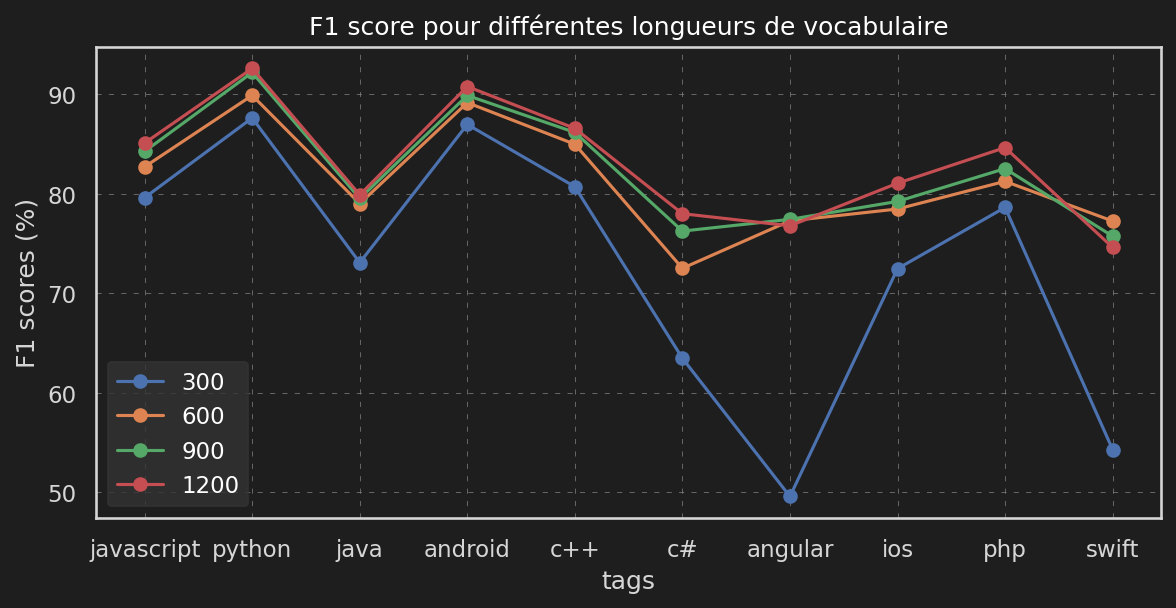

In [23]:
importlib.reload(funcs)
ax = funcs.plot_f1_scores(results, vectorised.get_prediction_tags())
ax.set_title('F1 score pour différentes longueurs de vocabulaire')

In [14]:
importlib.reload(funcs)
vectorised = funcs.Vectorised()
vectorised.initialize_data('tfidf',
                        funcs.concat_str_features(x_train, features),
                        y_train,
                        min_df=100, max_df=0.95, max_features=900
                        )
vectorised.set('test', funcs.concat_str_features(x_test, features))

vocaublary length: 900


## Optimisation des hyper paramètres

In [29]:
importlib.reload(funcs)
results = {}
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    tmp = funcs.Vectorised()
    tmp.copy_data_from_vetorizer(vectorised)
    t0 = time.time()
    tmp.train_classifier(model, kernel_params={'C':C})
    tmp.optimize_threshold()
    print('C: {:}, elapsed time: {:.2f} seconds'.format(C, time.time()-t0))

    y_pred = tmp.predict_optim_threshold('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()

    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    display(df_res)
    results[C] = df_res.iloc[-1, :]


filename = 'regularisation'
if True:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(results, file)
else:
    with open(path_results + filename, 'rb') as file:
        results = pickle.load(file)
del filename

C: 0.01, elapsed time: 79.07 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.34,93.90,82.99,92.47,87.78,77.05,83.48,78.37,87.31,77.30
recall,83.52,90.14,76.13,85.99,84.04,74.71,74.51,79.82,78.02,74.38
specificity,96.99,99.03,97.10,99.06,98.01,96.15,99.65,98.41,99.18,99.33
F1 score,83.93,91.98,79.41,89.12,85.87,75.86,78.74,79.09,82.41,75.81


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

C: 0.1, elapsed time: 209.68 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.64,94.57,83.60,92.30,88.90,77.10,81.12,80.09,87.31,79.20
recall,83.81,89.94,75.78,87.26,83.52,75.27,75.56,78.24,78.33,72.66
specificity,97.04,99.14,97.24,99.02,98.22,96.13,99.58,98.60,99.17,99.42
F1 score,84.22,92.20,79.50,89.71,86.13,76.18,78.24,79.16,82.57,75.79


...

C: 100, elapsed time: 215.48 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.60,94.10,83.48,93.23,88.42,76.30,80.17,78.83,86.11,78.40
recall,83.89,90.23,75.90,86.78,83.95,76.20,75.76,79.54,78.92,73.09
specificity,97.03,99.06,97.21,99.16,98.13,95.90,99.56,98.46,99.07,99.38
F1 score,84.24,92.13,79.51,89.89,86.13,76.25,77.90,79.18,82.36,75.65


/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

C: 1000, elapsed time: 223.08 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,84.60,94.38,83.48,93.23,88.42,76.29,80.19,78.83,86.10,78.38
recall,83.89,90.07,75.90,86.78,83.95,76.20,75.86,79.54,78.91,73.13
specificity,97.03,99.11,97.21,99.16,98.13,95.90,99.56,98.46,99.07,99.38
F1 score,84.24,92.17,79.51,89.89,86.13,76.25,77.97,79.18,82.35,75.66


Text(0.5, 1.0, 'F1 score pour différentes pénalités (l2)')

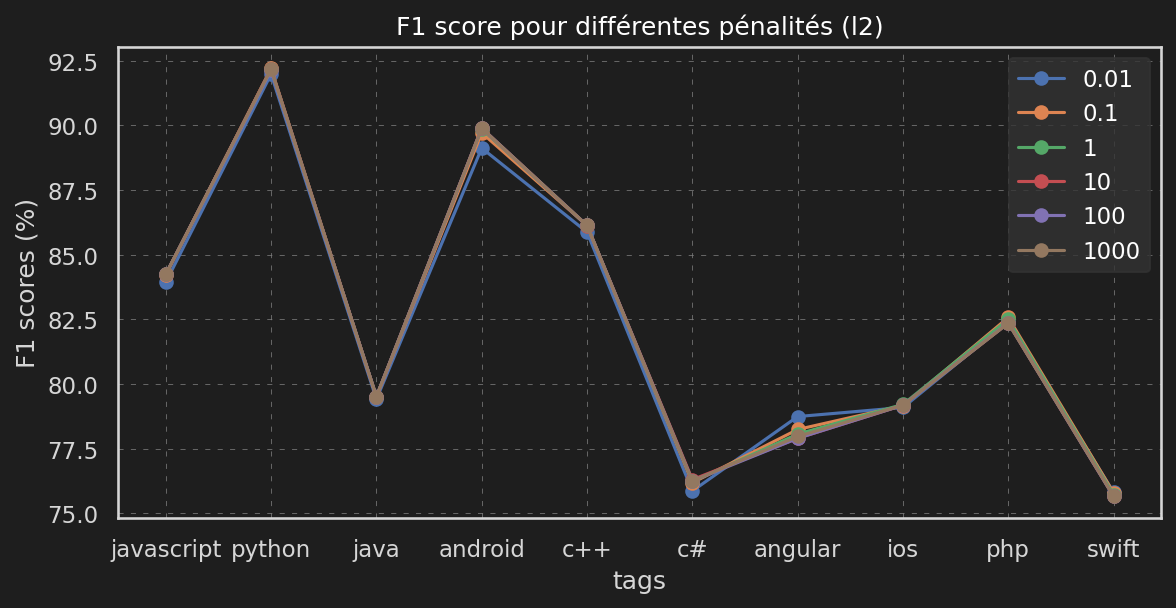

In [30]:
ax = funcs.plot_f1_scores(results, vectorised.get_prediction_tags())
ax.set_title('F1 score pour différentes pénalités (l2)')

## Extra Trees

<span style="color:red"> voir randomizeGridSearchCV </span> ?

In [10]:
param_grid = {
              'max_depth': [None],#, 5, 10],
              'max_features':[],
              'min_samples_split': [2], #, 4],
              'min_samples_leaf': [1], #, 4],
}

importlib.reload(funcs)
trees = funcs.train_extra_trees(vectorised, param_grid)

x_train: (86627, 900)
y_train: (86627, 10)
x_train: (10000, 900)
y_train: (10000, 10)
best parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
if True:
    with open('data/models/trees.pickle', 'wb') as file:
        pickle.dump(trees, file)
else:
    with open('data/models/trees.pickle', 'rb') as file:
        trees = pickle.load(file)

In [11]:
y_pred = trees.predict(vectorised.scale(vectorised.get('test')))
y_true = y_test.values
prediction_tags = vectorised.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,93.78,98.62,97.14,98.79,97.18,95.83,96.32,90.06,97.98,93.90
recall,69.86,81.57,57.64,70.77,69.29,39.70,28.79,51.27,55.38,44.39
specificity,99.10,99.81,99.69,99.88,99.66,99.70,99.97,99.59,99.92,99.91
F1 score,80.07,89.29,72.35,82.46,80.90,56.15,44.32,65.34,70.76,60.29


In [12]:
filename = 'data/results/trees.pickle'
with open(filename, 'wb') as file:
    pickle.dump(df_res, file)

In [158]:
def grid_search_cv_model(vectorised, model, param_grid):
    tmp = funcs.Vectorised()
    tmp.copy_data_from_vetorizer(vectorised)

    t0 = time.time()
    tmp.grid_search_cv(model, param_grid)
    print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

    y_pred = tmp.predict('test')
    y_true = y_test.values
    prediction_tags = tmp.get_prediction_tags()

    df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
    display(df_res)

## méthodes "Deep Learning"

### Word2Vect

<span style="color:red"> donner la limitation du mot par mot </span>

In [13]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('word2vec',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

<span style="color:red"> AJOUT SAUVERAGE DF_RES </span>

In [14]:
importlib.reload(funcs)
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values
prediction_tags = tmp.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

elapsed time: 103.38 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,71.35,77.26,65.29,78.04,80.55,56.54,64.18,64.58,68.02,61.71
recall,70.77,75.27,65.08,72.80,76.80,61.92,58.37,63.73,61.81,57.48
specificity,94.48,96.31,93.57,97.26,96.84,91.76,99.23,97.48,97.89,98.91
F1 score,71.06,76.26,65.19,75.32,78.63,59.11,61.14,64.15,64.77,59.52


In [15]:
filename = 'data/results/w2v.pickle'
with open(filename, 'wb') as file:
    pickle.dump(df_res, file)

### SBERT

<span style="color:red"> AJOUT : body + title cleaned </span>

In [17]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('sbert',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

In [18]:
importlib.reload(funcs)
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values
prediction_tags = tmp.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

elapsed time: 105.53 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,89.16,97.23,88.01,94.43,93.64,88.11,87.86,85.10,92.82,80.66
recall,88.94,93.57,81.13,91.45,89.71,82.59,85.76,89.78,88.01,70.99
specificity,97.90,99.56,97.95,99.28,98.96,98.07,99.72,98.87,99.50,99.48
F1 score,89.05,95.37,84.43,92.91,91.63,85.26,86.80,87.38,90.35,75.52


In [20]:
filename = 'SBERT.pickle'

if True:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(df_res, file)

    with open(path_models + filename, 'wb') as file:
        pickle.dump(tmp.__dict__, file)
else:
    with open(path_models + filename, 'rb') as file:
        dict_tmp = pickle.load(file)
        tmp = funcs.Vectorised()
        tmp.copy_data_from_dict(dict_tmp)

# filename = 'SBERT_x.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.get('train'), tmp.get('test')), file)
# filename = 'data/models/SBERT_y.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.y_train, y_test), file)

In [7]:
importlib.reload(funcs)

# filename = 'data/results/SBERT.pickle'
# with open(filename, 'rb') as file:
#     df_res_tmp = pickle.load(file)

# display(df_res_tmp)

# y_pred = tmp.predict_optim_threshold('test')
# df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
# display(df_res)

<module 'funcs' from '/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/funcs.py'>

In [8]:
features = ['Title_clean', 'Body_clean']

In [9]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('sbert',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

SBERT vectorization:
100.00%    

SBERT vectorization:
100.00%    



In [10]:
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values
prediction_tags = tmp.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-for

elapsed time: 103.46 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.27,97.48,88.90,94.63,94.36,91.54,89.61,86.92,94.60,81.51
recall,90.72,96.16,82.59,92.36,92.82,86.29,87.51,88.55,92.13,76.91
specificity,98.10,99.59,98.08,99.30,99.05,98.62,99.76,99.04,99.62,99.47
F1 score,90.49,96.82,85.62,93.48,93.58,88.84,88.55,87.73,93.35,79.14


In [12]:
filename = 'SBERT_on_clean.pickle'

if False:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(df_res, file)

    with open(path_models + filename, 'wb') as file:
        pickle.dump(tmp.__dict__, file)
else:
    with open(path_models + filename, 'rb') as file:
        dict_tmp = pickle.load(file)
        tmp = funcs.Vectorised()
        tmp.copy_data_from_dict(dict_tmp)

# filename = 'SBERT_x.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.get('train'), tmp.get('test')), file)
# filename = 'data/models/SBERT_y.pickle'
# with open(filename, 'wb') as file:
#     pickle.dump((tmp.y_train, y_test), file)

### Universal Sentence Encoder

<span style="color:red">

* regarder mémoire just avec model
* vectorisation phrase par phrase
</span>

In [19]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.initialize_data('use',
                    funcs.concat_str_features(x_train, features),
                    y_train,
                    )
tmp.set('test', funcs.concat_str_features(x_test, features))

2023-05-08 17:22:09.686432: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype string
	 [[{{node inputs}}]]


USE vectorization:
100.00%    

USE vectorization:
100.00%    



In [20]:
importlib.reload(funcs)
t0 = time.time()
tmp.train_classifier(model)
tmp.optimize_threshold()
print('elapsed time: {:.2f} seconds'.format(time.time()-t0))

y_pred = tmp.predict_optim_threshold('test')
y_true = y_test.values
prediction_tags = tmp.get_prediction_tags()

df_res = funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)
display(df_res)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


elapsed time: 97.06 seconds


,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,86.60,94.56,89.21,93.53,91.81,88.10,80.67,87.34,92.40,73.35
recall,86.07,91.77,79.81,89.71,89.23,84.44,78.41,84.79,87.79,71.69
specificity,97.41,99.12,98.21,99.17,98.64,98.03,99.56,99.11,99.47,99.20
F1 score,86.33,93.14,84.25,91.58,90.50,86.23,79.52,86.04,90.04,72.51


In [23]:
filename = 'USE.pickle'

if True:
    with open(path_results + filename, 'wb') as file:
        pickle.dump(df_res, file)

    with open(path_models + filename, 'wb') as file:
        tmp_dict = tmp.__dict__
        tmp_dict.pop('vectorizer')
        pickle.dump(tmp_dict, file)
else:
    with open(path_models + filename, 'rb') as file:
        dict_tmp = pickle.load(file)
        tmp = funcs.Vectorised()
        tmp.copy_data_from_dict(dict_tmp)
        # ! AJOUT VECTORIZER

### Conclusions

Text(0.5, 1.0, 'F1 score pour différentes véctorisations')

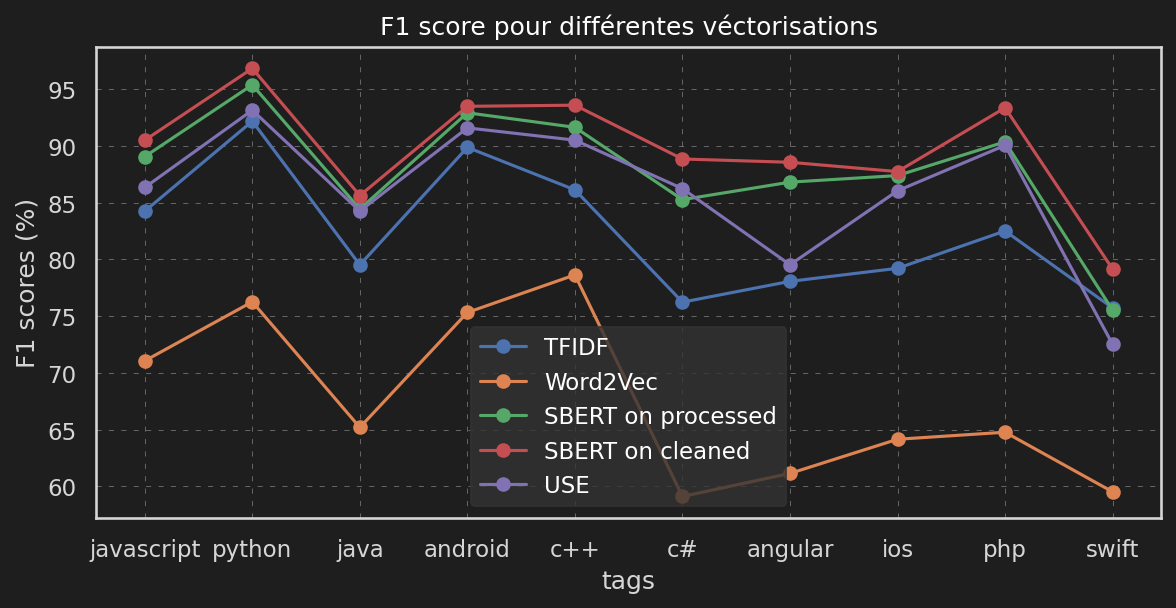

In [16]:
df_res = {}
with open(path_results + 'regularisation', 'rb') as file:
    df_res['TFIDF'] = pickle.load(file)[1]

with open(path_results + 'w2v.pickle', 'rb') as file:
    df_res['Word2Vec'] = pickle.load(file).iloc[-1,:]

with open(path_results + 'SBERT.pickle', 'rb') as file:
    df_res['SBERT on processed'] = pickle.load(file).iloc[-1,:]

with open(path_results + 'SBERT_on_clean.pickle', 'rb') as file:
    df_res['SBERT on cleaned'] = pickle.load(file).iloc[-1,:]

with open(path_results + 'USE.pickle', 'rb') as file:
    df_res['USE'] = pickle.load(file).iloc[-1,:]

ax = funcs.plot_f1_scores(df_res, vectorised.get_prediction_tags())
ax.set_title('F1 score pour différentes véctorisations')

---

<span style="color:red"> calcul input LDA </span>

miss rate or false negative rate (FNR)
FNR = FN/P = FN / (FN+TP) = 1 − TPR = 1 - recall

$$ {\displaystyle \mathrm {FNR} ={\frac {\mathrm {FN} }{\mathrm {P} }}={\frac {\mathrm {FN} }{\mathrm {FN} +\mathrm {TP} }}=1-\mathrm {TPR} } $$


condition positive (P)
the number of real positive cases in the data

condition negative (N)
the number of real negative cases in the data

true positive (TP)
A test result that correctly indicates the presence of a condition or characteristic

true negative (TN)
A test result that correctly indicates the absence of a condition or characteristic

false positive (FP)
A test result which wrongly indicates that a particular condition or attribute is present

false negative (FN)
A test result which wrongly indicates that a particular condition or attribute is absent
sensitivity, recall, hit rate, or true positive rate (TPR)

$$
{\displaystyle \mathrm {TPR} ={\frac {\mathrm {TP} }{\mathrm {P} }}={\frac {\mathrm {TP} }{\mathrm {TP} +\mathrm {FN} }}=1-\mathrm {FNR} }

$$
specificity, selectivity or true negative rate (TNR)

$$
{\displaystyle \mathrm {TNR} ={\frac {\mathrm {TN} }{\mathrm {N} }}={\frac {\mathrm {TN} }{\mathrm {TN} +\mathrm {FP} }}=1-\mathrm {FPR} }
$$

precision or positive predictive value (PPV)

$$
{\displaystyle \mathrm {PPV} ={\frac {\mathrm {TP} }{\mathrm {TP} +\mathrm {FP} }}=1-\mathrm {FDR} }
$$

negative predictive value (NPV)
$$
{\displaystyle \mathrm {NPV} ={\frac {\mathrm {TN} }{\mathrm {TN} +\mathrm {FN} }}=1-\mathrm {FOR} }
$$

miss rate or false negative rate (FNR)
$${\displaystyle \mathrm {FNR} ={\frac {\mathrm {FN} }{\mathrm {P} }}={\frac {\mathrm {FN} }{\mathrm {FN} +\mathrm {TP} }}=1-\mathrm {TPR} }
$$

fall-out or false positive rate (FPR)
$$
{\displaystyle \mathrm {FPR} ={\frac {\mathrm {FP} }{\mathrm {N} }}={\frac {\mathrm {FP} }{\mathrm {FP} +\mathrm {TN} }}=1-\mathrm {TNR} }
$$

false discovery rate (FDR)
$$
{\displaystyle \mathrm {FDR} ={\frac {\mathrm {FP} }{\mathrm {FP} +\mathrm {TP} }}=1-\mathrm {PPV} }
$$

false omission rate (FOR)
$${\displaystyle \mathrm {FOR} ={\frac {\mathrm {FN} }{\mathrm {FN} +\mathrm {TN} }}=1-\mathrm {NPV} }
$$

Positive likelihood ratio (LR+)
$${\displaystyle \mathrm {LR+} ={\frac {\mathrm {TPR} }{\mathrm {FPR} }}}
$$

Negative likelihood ratio (LR-)
$${\displaystyle \mathrm {LR-} ={\frac {\mathrm {FNR} }{\mathrm {TNR} }}}
$$

prevalence threshold (PT)
$${\displaystyle \mathrm {PT} ={\frac {\sqrt {\mathrm {FPR} }}{{\sqrt {\mathrm {TPR} }}+{\sqrt {\mathrm {FPR} }}}}}
$$

threat score (TS) or critical success index (CSI)
$${\displaystyle \mathrm {TS} ={\frac {\mathrm {TP} }{\mathrm {TP} +\mathrm {FN} +\mathrm {FP} }}}
$$

Prevalence
$${\displaystyle {\frac {\mathrm {P} }{\mathrm {P} +\mathrm {N} }}}
$$

accuracy (ACC)
$${\displaystyle \mathrm {ACC} ={\frac {\mathrm {TP} +\mathrm {TN} }{\mathrm {P} +\mathrm {N} }}={\frac {\mathrm {TP} +\mathrm {TN} }{\mathrm {TP} +\mathrm {TN} +\mathrm {FP} +\mathrm {FN} }}}
$$

balanced accuracy (BA)
$${\displaystyle \mathrm {BA} ={\frac {TPR+TNR}{2}}}
$$

F1 score is the harmonic mean of precision and sensitivity: 
$${\displaystyle \mathrm {F} _{1}=2\times {\frac {\mathrm {PPV} \times \mathrm {TPR} }{\mathrm {PPV} +\mathrm {TPR} }}={\frac {2\mathrm {TP} }{2\mathrm {TP} +\mathrm {FP} +\mathrm {FN} }}}
$$

phi coefficient (φ or rφ) or Matthews correlation coefficient (MCC)
$${\displaystyle \mathrm {MCC} ={\frac {\mathrm {TP} \times \mathrm {TN} -\mathrm {FP} \times \mathrm {FN} }{\sqrt {(\mathrm {TP} +\mathrm {FP} )(\mathrm {TP} +\mathrm {FN} )(\mathrm {TN} +\mathrm {FP} )(\mathrm {TN} +\mathrm {FN} )}}}}
$$

Fowlkes–Mallows index (FM)
$${\displaystyle \mathrm {FM} ={\sqrt {{\frac {TP}{TP+FP}}\times {\frac {TP}{TP+FN}}}}={\sqrt {PPV\times TPR}}}
$$

informedness or bookmaker informedness (BM)
$${\displaystyle \mathrm {BM} =\mathrm {TPR} +\mathrm {TNR} -1}
$$

markedness (MK) or deltaP (Δp)
$${\displaystyle \mathrm {MK} =\mathrm {PPV} +\mathrm {NPV} -1}
$$

Diagnostic odds ratio (DOR)
$${\displaystyle \mathrm {DOR} ={\frac {\mathrm {LR+} }{\mathrm {LR-} }}}
$$

essaie sans PCA

In [14]:
y_pred = vectorised.predict('train')
prediction_tags = vectorised.get_prediction_tags()
y_true = y_train.values

funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,92.27,98.29,91.46,98.03,94.31,88.91,97.63,93.49,96.19,95.72
recall,86.84,94.67,79.06,93.09,88.25,78.94,91.98,86.49,87.30,85.67
specificity,98.63,99.72,98.62,99.75,99.08,98.28,99.95,99.58,99.74,99.89
F1 score,89.47,96.45,84.81,95.50,91.18,83.63,94.72,89.86,91.53,90.42


In [20]:
y_pred = vectorised.predict_optim_threshold('train')
funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,90.79,97.32,85.83,96.86,91.87,83.81,95.43,91.00,94.41,93.06
recall,89.05,96.11,84.57,95.03,90.72,83.85,96.06,90.15,90.11,92.03
specificity,98.30,99.55,97.39,99.58,98.61,97.17,99.90,99.38,99.59,99.80
F1 score,89.91,96.71,85.19,95.94,91.29,83.83,95.74,90.57,92.21,92.54


essaie avec PCA

In [25]:
importlib.reload(funcs)
tmp = funcs.Vectorised()
tmp.copy_data_from_vetorizer(vectorised)
vectorised = tmp
del tmp

In [31]:
vectorised.train_classifier('logisticregression', n_pca_components=300)

/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/.venv/lib64/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [32]:
vectorised.optimize_threshold()
y_pred = vectorised.predict_optim_threshold('train')
funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,82.62,89.97,79.60,86.92,86.37,75.15,84.16,78.88,84.02,80.40
recall,81.51,85.17,72.69,82.82,83.61,69.61,76.08,84.26,71.05,68.31
specificity,96.77,98.40,96.52,98.32,97.72,95.98,99.68,98.44,98.97,99.51
F1 score,82.06,87.50,75.99,84.82,84.97,72.28,79.92,81.48,76.99,73.87


In [ ]:
importlib.reload(funcs)
y_pred = vectorised.predict('train')
prediction_tags = vectorised.get_prediction_tags()
y_true = y_train.values

funcs.simple_metric_dataframe(y_true, y_pred, prediction_tags)

,javascript,python,java,android,c++,c#,angular,ios,php,swift
precision,91.02,97.51,90.92,96.81,92.77,86.45,96.21,90.60,94.89,92.35
recall,83.11,91.96,74.56,90.50,84.93,73.51,86.73,80.78,83.88,79.21
specificity,98.45,99.61,98.61,99.60,98.86,97.99,99.92,99.42,99.66,99.81
F1 score,86.88,94.66,81.93,93.55,88.68,79.46,91.22,85.41,89.04,85.28


In [70]:
vectorised.pca_fit_on_train(1000)

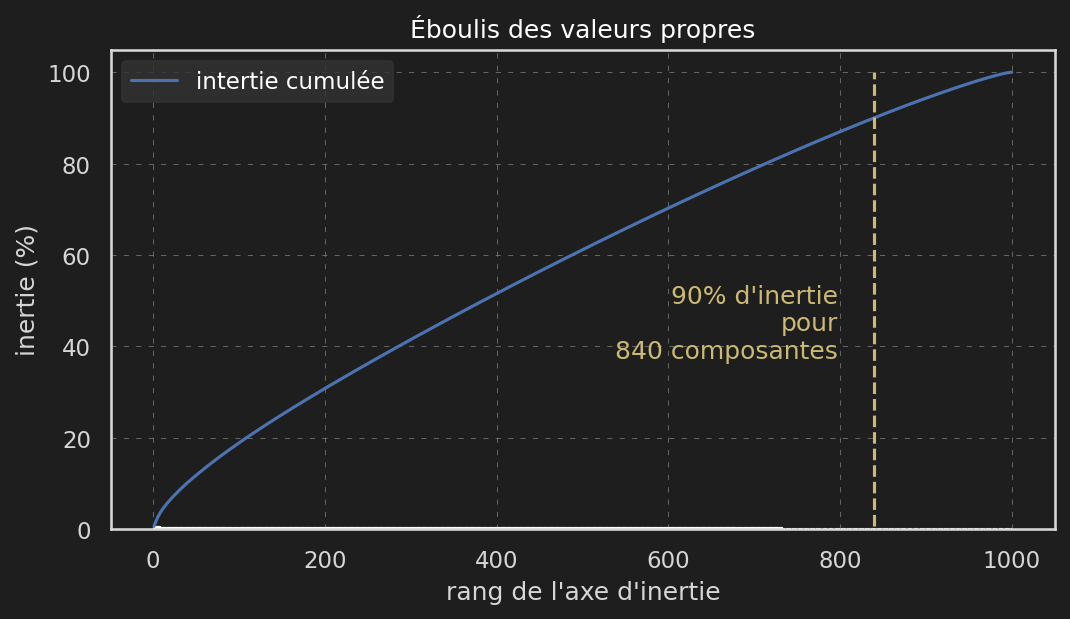

In [72]:
importlib.reload(funcs)
funcs.plot_ebouli_pca(vectorised.pca, 90, 'ebouli_tfidf')

In [33]:
# print('count vectorizer vocabulary:', len(cv['vocabulary']))
# print('TFIDF vectorizer vocabulary:', len(ctf['vocabulary']))

TFIDF vectorizer vocabulary: 1000


In [21]:
y_train.shape

(34651, 10)

In [23]:
vectorised.get('train').shape

(34651, 1000)

In [27]:
# vectorised.train_classifier('svc', y_train)


UnboundLocalError: local variable 'clf' referenced before assignment

x: (138604, 1000)
vocabulary: 1000

x sum axis=0: (1000,)
most used terms (decreasing order)
['file' 'class' 'string' 'function' 'error' 'new' 'code' 'using' 'return'
 'public' 'int' 'application' 'android' 'get' 'like' 'value' 'use' 'would'
 'object' 'type' 'method' 'data' 'way' 'name' 'var' 'want' 'std' 'work'
 'import' 'python' 'array' 'one' 'void' 'line' 'need' 'time' 'java' 'set'
 'user' 'following' 'test' 'list' 'know' '124' 'example' 'cannot'
 'problem' 'id' 'true' 'null' 'image' 'result' 'run' 'project' 'tried'
 'call' 'could' 'something' 'trying' 'number' 'question' 'make' 'find'
 'version' 'also' 'text' 'static' 'exception' 'private' 'javascript'
 'const' 'php' 'possible' 'view' 'variable' 'element' 'print' 'server'
 'change' 'create' 'div' 'script' 'case' 'false' 'message' 'see' 'window'
 'key' 'library' 'page' 'first' 'found' 'two' 'add' '10' 'working' 'try'
 'main' 'however' 'thread' 'request' 'item' 'without' 'foo' 'input' 'url'
 'used' 'output' 'solution' 'let' 'property

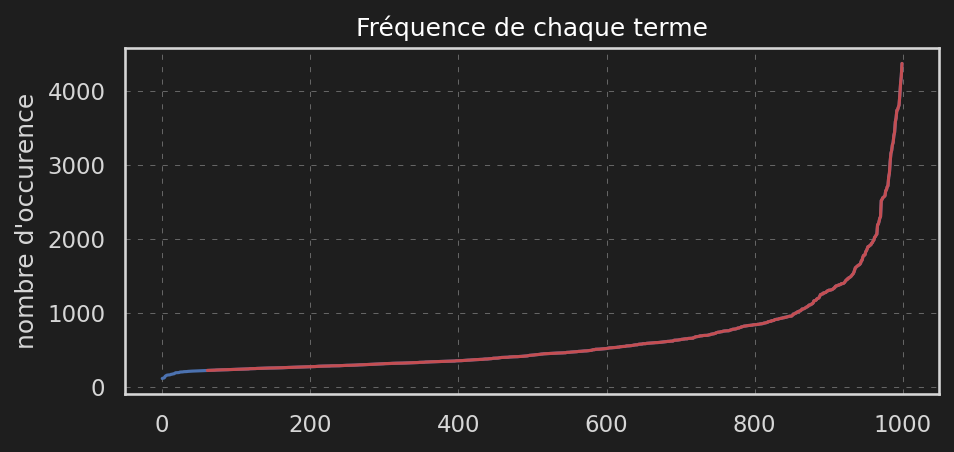

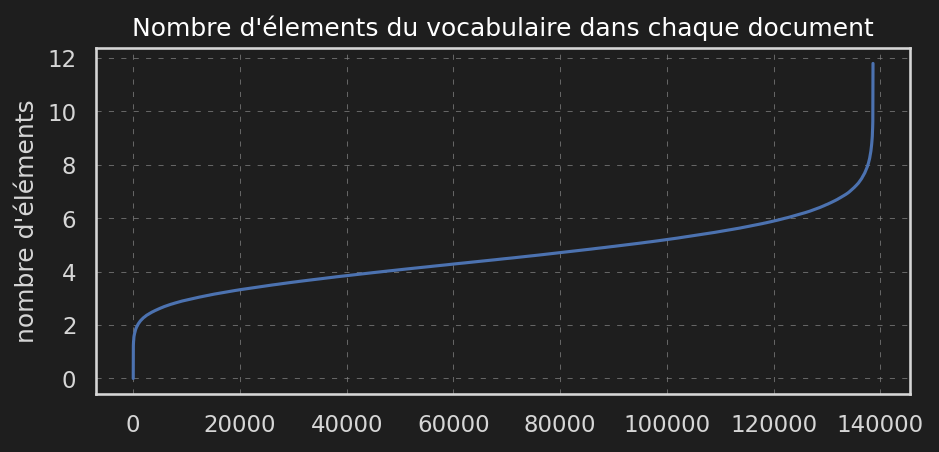

In [37]:
funcs.plot_sum_vectorizer(funcs.concat_str_features(x_train, features), ctf)

In [11]:
vis = funcs.init_lda(ctf, len(tags['most used']))

LDA: 20 topics
iteration: 1 of max_iter: 10
iteration: 2 of max_iter: 10
iteration: 3 of max_iter: 10
iteration: 4 of max_iter: 10
iteration: 5 of max_iter: 10
iteration: 6 of max_iter: 10
iteration: 7 of max_iter: 10
iteration: 8 of max_iter: 10
iteration: 9 of max_iter: 10
iteration: 10 of max_iter: 10


In [16]:
funcs.show_lda_vis(vis)

In [14]:
funcs.save_LDAvis(vis)

## métrique simple:
* recall | sensitivity : taux de vrai positif
* 1 - recall | 1 - sensitivity : taux de faux négatif
* specificity : taux de vrai négatif
* anti-specificity (1 - specificity): taux faux positif
* precision : proportion de prédictions correctes parmi les points prédits positifs

In [ ]:
# precision, recall, specificity = funcs.compute_simple_metric(y_true, y_pred)

In [43]:
importlib.reload(funcs)

<module 'funcs' from '/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/05_Cétégoriser_automatiquement_des_questions/funcs.py'>

In [44]:
funcs.vectorized_add_scaler(ctf)

<span style="color:red"> TODO: </span>
> * fonction concat -> DF, features -> concat strings
> * fonction init, compute, score, store, plot model

In [21]:
importlib.reload(funcs)
clf_0 = funcs.process_mutlilabel_classifier(cv, y_train, y_test)

In [13]:
importlib.reload(funcs)
clf_svd = funcs.process_mutlilabel_classifier(cv, y_train, y_test, 'svd')

In [ ]:
import pickle
with open('clf_0', 'wb') as file:
    pickle.dump(clf_0, file)
with open('clf_svd', 'wb') as file:
    pickle.dump(clf_svd, file)

In [9]:
print("CountVectorizer : ")
print("-----------------")
ARI, X_tsne, labels = funcs.ARI_fct(cv_transform, [0,1], y_tag)

CountVectorizer : 
-----------------


KeyboardInterrupt: 

In [ ]:
funcs.TSNE_visu_fct(X_tsne, y_tag, labels, ARI)

In [ ]:


print()
print("Tf-idf : ")
print("--------")
ARI, X_tsne, labels = ARI_fct(ctf_transform)

CountVectorizer : 
-----------------
